# Machine Learning Pipeline

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from joblib import dump, load

Reading the dataset

In [ ]:
df = pd.read_parquet(r"Samples\sample_2009_2010_large_clean.parquet")

In [ ]:
df

,index,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,Total_Amt,pickup_date,year_month,day
0,0,CMT,2009-01-01 04:50:51,2009-01-01 04:57:58,2,1.10,-73.992557,40.725880,-73.983352,40.718691,Cash,6.2,0.0,0.00,0.00,6.20,2009-01-01 04:50:51,2009-01,1
1,1,CMT,2009-01-01 12:21:34,2009-01-01 12:22:12,3,0.00,-73.975840,40.750331,-73.975840,40.750331,Credit,45.0,0.0,5.00,9.15,59.15,2009-01-01 12:21:34,2009-01,1
2,2,CMT,2009-01-01 16:17:37,2009-01-01 16:37:43,1,3.60,-73.976593,40.751878,-73.991894,40.713904,Credit,13.3,0.0,2.00,0.00,15.30,2009-01-01 16:17:37,2009-01,1
3,3,VTS,2009-01-01 14:28:00,2009-01-01 14:35:00,2,2.52,-73.971420,40.746892,-73.948028,40.778605,CASH,8.1,0.0,0.00,0.00,8.10,2009-01-01 14:28:00,2009-01,1
4,4,CMT,2009-01-01 01:22:43,2009-01-01 01:36:47,2,3.10,-73.971475,40.787167,-73.974972,40.753623,Cash,11.4,0.0,0.00,0.00,11.40,2009-01-01 01:22:43,2009-01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119376,4685,CMT,2011-02-22 20:09:04,2011-02-22 20:18:16,2,1.60,-74.004256,40.730409,-73.982987,40.721102,CAS,7.3,0.5,0.00,0.00,8.30,2011-02-22 20:09:04,2011-02,22
119377,4686,CMT,2011-02-22 19:51:50,2011-02-22 20:01:05,1,1.40,-74.013464,40.717366,-73.996672,40.722204,CRE,7.3,0.5,1.66,0.00,9.96,2011-02-22 19:51:50,2011-02,22
119378,4687,CMT,2011-02-22 20:24:52,2011-02-22 20:34:01,1,3.70,-73.988055,40.723760,-73.953078,40.771506,CRE,10.1,0.5,1.00,0.00,12.10,2011-02-22 20:24:52,2011-02,22
119379,4688,CMT,2011-02-22 20:38:05,2011-02-22 20:41:55,1,1.30,-73.950901,40.776661,-73.960971,40.761586,CAS,4.9,0.5,0.00,0.00,5.90,2011-02-22 20:38:05,2011-02,22


Processing the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119381 entries, 0 to 119380
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   index                  119381 non-null  int64         
 1   vendor_name            119381 non-null  object        
 2   Trip_Pickup_DateTime   119381 non-null  object        
 3   Trip_Dropoff_DateTime  119381 non-null  object        
 4   Passenger_Count        119381 non-null  int64         
 5   Trip_Distance          119381 non-null  float64       
 6   Start_Lon              119381 non-null  float64       
 7   Start_Lat              119381 non-null  float64       
 8   End_Lon                119381 non-null  float64       
 9   End_Lat                119381 non-null  float64       
 10  Payment_Type           119381 non-null  object        
 11  Fare_Amt               119381 non-null  float64       
 12  surcharge              119381 non-null  floa

Convert in DateTime

In [ ]:
df['Trip_Pickup_DateTime'] = pd.to_datetime(df['Trip_Pickup_DateTime'])
df['Trip_Dropoff_DateTime'] = pd.to_datetime(df['Trip_Dropoff_DateTime'])

We are only using he years 2009 and 2010

In [ ]:
# Filter rows where the year is 2009 or 2010
df = df[df['Trip_Pickup_DateTime'].dt.year.isin([2009, 2010])]

We are removing what is not necessary

In [ ]:
df = df.drop(columns=['index', 'pickup_date'])

Checking for spelling variations within columns

In [ ]:
print("Unique Values in Payment_Type:")
print(df['Payment_Type'].unique())

print("\nUnique Values in vendor_name:")
print(df['vendor_name'].unique())

Unique Values in Payment_Type:
['Cash' 'Credit' 'CASH' 'No Charge' 'CREDIT' 'Dispute' 'CAS' 'Cas' 'Cre'
 'No ' 'Dis' 'CRE' 'NA ' 'CSH' 'CRD' 'DIS' 'NOC']

Unique Values in vendor_name:
['CMT' 'VTS' 'DDS']


Correcting it

In [ ]:
mapping_payment = {
    'CASH': 'CASH', 'CAS': 'CASH', 'Cas': 'CASH', 'CSH': 'CASH', 'Cash': 'CASH',
    'CREDIT': 'CREDIT', 'Cre': 'CREDIT', 'CRD': 'CREDIT', 'CRE': 'CREDIT', 'Credit': 'CREDIT',
    'NO CHARGE': 'NO_CHARGE', 'No ': 'NO_CHARGE', 'NOC': 'NO_CHARGE', 'NA ': 'NO_CHARGE', 'No Charge': 'NO_CHARGE',
    'DISPUTE': 'DISPUTE', 'Dis': 'DISPUTE', 'DIS': 'DISPUTE', 'Dispute': 'DISPUTE'
}

# Transform to uppercase and apply mapping
df['Payment_Type'] = df['Payment_Type'].str.upper().map(mapping_payment)

Normalizing the previous columns with One-Hot-Encoder

In [ ]:
df = pd.get_dummies(df, columns=['Payment_Type', 'vendor_name'], drop_first=False)

Creating new Features

In [ ]:
df['Trip_Pickup_DateTime'] = pd.to_datetime(df['Trip_Pickup_DateTime'])
df['Trip_Dropoff_DateTime'] = pd.to_datetime(df['Trip_Dropoff_DateTime'])

df['trip_duration_sec'] = (df['Trip_Dropoff_DateTime'] - df['Trip_Pickup_DateTime']).dt.total_seconds()

In [ ]:
# Create the Fare_per_mile feature
df['Fare_per_mile'] = df.apply(lambda row: row['Fare_Amt'] / row['Trip_Distance']
                              if row['Trip_Distance'] > 0 else 0, axis=1)

In [ ]:
# Create the Tip_percent feature (tip percentage on the fare)
df['Tip_percent'] = df.apply(lambda row: row['Tip_Amt'] / row['Fare_Amt']
                            if row['Fare_Amt'] > 0 else 0, axis=1)

We will use DBSCAN to cluster pickup coordinates based on density, allowing automatic discovery of spatial zones.

This will help capture neighborhood-like groupings without specifying the number of clusters.



We're using HDBSCAN because it handles large datasets more efficiently than DBSCAN, avoiding memory issues.

It also automatically finds the optimal number of clusters based on density, which is well-suited for geospatial data like pickup locations.

In [ ]:
import hdbscan
from sklearn.preprocessing import StandardScaler

coords = df[['Start_Lon', 'Start_Lat']].dropna()
coords_scaled = StandardScaler().fit_transform(coords)

# HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
labels = clusterer.fit_predict(coords_scaled)

df['pickup_zone'] = -1
df.loc[coords.index, 'pickup_zone'] = labels

c:\Users\InesNeves\anaconda3\envs\ML_cdle\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\InesNeves\anaconda3\envs\ML_cdle\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
df

,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Fare_Amt,surcharge,...,Payment_Type_CREDIT,Payment_Type_DISPUTE,Payment_Type_NO_CHARGE,vendor_name_CMT,vendor_name_DDS,vendor_name_VTS,trip_duration_sec,Fare_per_mile,Tip_percent,pickup_zone
0,2009-01-01 04:50:51,2009-01-01 04:57:58,2,1.10,-73.992557,40.725880,-73.983352,40.718691,6.2,0.0,...,False,False,False,True,False,False,427.0,5.636364,0.000000,16
1,2009-01-01 12:21:34,2009-01-01 12:22:12,3,0.00,-73.975840,40.750331,-73.975840,40.750331,45.0,0.0,...,True,False,False,True,False,False,38.0,0.000000,0.111111,16
2,2009-01-01 16:17:37,2009-01-01 16:37:43,1,3.60,-73.976593,40.751878,-73.991894,40.713904,13.3,0.0,...,True,False,False,True,False,False,1206.0,3.694444,0.150376,16
3,2009-01-01 14:28:00,2009-01-01 14:35:00,2,2.52,-73.971420,40.746892,-73.948028,40.778605,8.1,0.0,...,False,False,False,False,False,True,420.0,3.214286,0.000000,16
4,2009-01-01 01:22:43,2009-01-01 01:36:47,2,3.10,-73.971475,40.787167,-73.974972,40.753623,11.4,0.0,...,False,False,False,True,False,False,844.0,3.677419,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119367,2010-12-31 14:04:41,2010-12-31 14:17:23,1,1.50,-73.992501,40.734102,-74.000967,40.746380,8.1,0.0,...,False,False,False,True,False,False,762.0,5.400000,0.000000,16
119368,2010-12-31 21:51:00,2010-12-31 22:04:00,1,1.58,-73.989103,40.509162,-73.992605,40.503565,8.5,0.5,...,False,False,False,False,False,True,780.0,5.379747,0.000000,-1
119369,2010-12-31 18:24:00,2010-12-31 18:30:00,1,0.90,-73.997662,40.722557,-73.984913,40.724035,5.3,1.0,...,False,False,False,False,False,True,360.0,5.888889,0.000000,16
119370,2010-12-31 19:43:00,2010-12-31 19:48:00,1,1.27,-73.955403,40.764567,-73.969085,40.753820,5.3,0.0,...,False,False,False,False,False,True,300.0,4.173228,0.000000,16


In [ ]:
# PICKUP
df['pickup_hour'] = df['Trip_Pickup_DateTime'].dt.hour
df['pickup_dayofweek'] = df['Trip_Pickup_DateTime'].dt.dayofweek + 1 # 1 = Monday
df['pickup_month'] = df['Trip_Pickup_DateTime'].dt.month
df['pickup_year'] = df['Trip_Pickup_DateTime'].dt.year

# DROPOFF
df['dropoff_hour'] = df['Trip_Dropoff_DateTime'].dt.hour
df['dropoff_dayofweek'] = df['Trip_Dropoff_DateTime'].dt.dayofweek + 1 # 1 = Monday
df['dropoff_month'] = df['Trip_Dropoff_DateTime'].dt.month
df['dropoff_year'] = df['Trip_Dropoff_DateTime'].dt.year

# Delete original columns
df.drop(columns=[
    'Trip_Pickup_DateTime',
    'Trip_Dropoff_DateTime',
    'year_month',
    'day'
], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119372 entries, 0 to 119371
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Passenger_Count         119372 non-null  int64  
 1   Trip_Distance           119372 non-null  float64
 2   Start_Lon               119372 non-null  float64
 3   Start_Lat               119372 non-null  float64
 4   End_Lon                 119372 non-null  float64
 5   End_Lat                 119372 non-null  float64
 6   Fare_Amt                119372 non-null  float64
 7   surcharge               119372 non-null  float64
 8   Tip_Amt                 119372 non-null  float64
 9   Tolls_Amt               119372 non-null  float64
 10  Total_Amt               119372 non-null  float64
 11  Payment_Type_CASH       119372 non-null  bool   
 12  Payment_Type_CREDIT     119372 non-null  bool   
 13  Payment_Type_DISPUTE    119372 non-null  bool   
 14  Payment_Type_NO_CHARGE  1

In [ ]:
df.describe()

,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,...,Tip_percent,pickup_zone,pickup_hour,pickup_dayofweek,pickup_month,pickup_year,dropoff_hour,dropoff_dayofweek,dropoff_month,dropoff_year
count,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,...,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000,119372.000000
mean,1.682999,2.727153,-72.769082,40.087667,-72.787045,40.098582,9.922547,0.267596,0.670304,0.167025,...,0.064377,14.938964,13.520222,4.000637,6.485507,2009.498702,13.503192,4.003284,6.485566,2009.498718
std,1.246309,3.141106,9.367972,5.160755,9.296009,5.118855,7.786253,0.354794,1.541925,0.902405,...,0.186937,3.792245,6.512149,1.997783,3.445384,0.500000,6.581217,1.999352,3.445394,0.500000
min,0.000000,0.000000,-82.544768,-0.095012,-82.544768,-0.095502,-56.100000,-1.000000,0.000000,0.000000,...,0.000000,-1.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,1.000000,1.000000,2009.000000
25%,1.000000,1.000000,-73.991852,40.735893,-73.991433,40.734790,5.700000,0.000000,0.000000,0.000000,...,0.000000,16.000000,9.000000,2.000000,3.000000,2009.000000,9.000000,2.000000,3.000000,2009.000000
50%,1.000000,1.700000,-73.981646,40.753303,-73.980217,40.753408,7.700000,0.000000,0.000000,0.000000,...,0.000000,16.000000,14.000000,4.000000,6.000000,2009.000000,14.000000,4.000000,6.000000,2009.000000
75%,2.000000,3.070000,-73.967491,40.767528,-73.964495,40.768263,11.300000,0.500000,1.000000,0.000000,...,0.136986,16.000000,19.000000,6.000000,9.000000,2010.000000,19.000000,6.000000,9.000000,2010.000000
max,6.000000,47.740000,0.004200,42.798333,0.010290,42.833165,191.000000,1.500000,92.000000,19.500000,...,34.000000,16.000000,23.000000,7.000000,12.000000,2010.000000,23.000000,7.000000,12.000000,2010.000000


Removing Anomalies:
- Passenger_Count ---> 0
- Trip_Distance ---> 0
- Negative Fare_Amt

In [ ]:
df = df[df['Passenger_Count'] > 0]
df = df[df['Trip_Distance'] > 0]
df = df[df['Fare_Amt'] >= 0]

In [ ]:
df

,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,...,Tip_percent,pickup_zone,pickup_hour,pickup_dayofweek,pickup_month,pickup_year,dropoff_hour,dropoff_dayofweek,dropoff_month,dropoff_year
0,2,1.10,-73.992557,40.725880,-73.983352,40.718691,6.2,0.0,0.0,0.0,...,0.000000,16,4,4,1,2009,4,4,1,2009
2,1,3.60,-73.976593,40.751878,-73.991894,40.713904,13.3,0.0,2.0,0.0,...,0.150376,16,16,4,1,2009,16,4,1,2009
3,2,2.52,-73.971420,40.746892,-73.948028,40.778605,8.1,0.0,0.0,0.0,...,0.000000,16,14,4,1,2009,14,4,1,2009
4,2,3.10,-73.971475,40.787167,-73.974972,40.753623,11.4,0.0,0.0,0.0,...,0.000000,16,1,4,1,2009,1,4,1,2009
5,5,1.34,-73.992482,40.714273,-73.982358,40.731828,5.7,0.0,0.0,0.0,...,0.000000,16,10,4,1,2009,10,4,1,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119367,1,1.50,-73.992501,40.734102,-74.000967,40.746380,8.1,0.0,0.0,0.0,...,0.000000,16,14,5,12,2010,14,5,12,2010
119368,1,1.58,-73.989103,40.509162,-73.992605,40.503565,8.5,0.5,0.0,0.0,...,0.000000,-1,21,5,12,2010,22,5,12,2010
119369,1,0.90,-73.997662,40.722557,-73.984913,40.724035,5.3,1.0,0.0,0.0,...,0.000000,16,18,5,12,2010,18,5,12,2010
119370,1,1.27,-73.955403,40.764567,-73.969085,40.753820,5.3,0.0,0.0,0.0,...,0.000000,16,19,5,12,2010,19,5,12,2010


## Feature Importance com RandomForestRegressor

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

Features e Target

In [ ]:
X = df.drop(columns=['Fare_Amt'])
y = df['Fare_Amt']

Train and Test Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

Training the model

In [ ]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt'
}

model = lgb.train(params, train_data, valid_sets=[valid_data])

Feature Importance

In [ ]:
importance = model.feature_importance()
feature_names = X.columns


feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

In [ ]:
feat_imp_df

,feature,importance
9,Total_Amt,898
18,Fare_per_mile,344
17,trip_duration_sec,342
1,Trip_Distance,327
19,Tip_percent,304
8,Tolls_Amt,185
7,Tip_Amt,155
6,surcharge,112
23,pickup_month,48
21,pickup_hour,39


Remove least important features

In [ ]:
# List of columns to remove (low importance)
cols_to_drop = [
    'dropoff_dayofweek',
    'Payment_Type_CREDIT',
    'Payment_Type_CASH',
    'vendor_name_CMT',
    'Passenger_Count',
    'vendor_name_VTS',
    'Payment_Type_CASH',
    'Payment_Type_DISPUTE',
    'Payment_Type_NO_CHARGE',
]

# Remove columns from dataframe
df = df.drop(columns=cols_to_drop)

In [ ]:
df

,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,Total_Amt,...,Fare_per_mile,Tip_percent,pickup_zone,pickup_hour,pickup_dayofweek,pickup_month,pickup_year,dropoff_hour,dropoff_month,dropoff_year
0,1.10,-73.992557,40.725880,-73.983352,40.718691,6.2,0.0,0.0,0.0,6.2,...,5.636364,0.000000,16,4,4,1,2009,4,1,2009
2,3.60,-73.976593,40.751878,-73.991894,40.713904,13.3,0.0,2.0,0.0,15.3,...,3.694444,0.150376,16,16,4,1,2009,16,1,2009
3,2.52,-73.971420,40.746892,-73.948028,40.778605,8.1,0.0,0.0,0.0,8.1,...,3.214286,0.000000,16,14,4,1,2009,14,1,2009
4,3.10,-73.971475,40.787167,-73.974972,40.753623,11.4,0.0,0.0,0.0,11.4,...,3.677419,0.000000,16,1,4,1,2009,1,1,2009
5,1.34,-73.992482,40.714273,-73.982358,40.731828,5.7,0.0,0.0,0.0,5.7,...,4.253731,0.000000,16,10,4,1,2009,10,1,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119367,1.50,-73.992501,40.734102,-74.000967,40.746380,8.1,0.0,0.0,0.0,8.6,...,5.400000,0.000000,16,14,5,12,2010,14,12,2010
119368,1.58,-73.989103,40.509162,-73.992605,40.503565,8.5,0.5,0.0,0.0,9.5,...,5.379747,0.000000,-1,21,5,12,2010,22,12,2010
119369,0.90,-73.997662,40.722557,-73.984913,40.724035,5.3,1.0,0.0,0.0,6.8,...,5.888889,0.000000,16,18,5,12,2010,18,12,2010
119370,1.27,-73.955403,40.764567,-73.969085,40.753820,5.3,0.0,0.0,0.0,5.8,...,4.173228,0.000000,16,19,5,12,2010,19,12,2010


# Understanding the Target

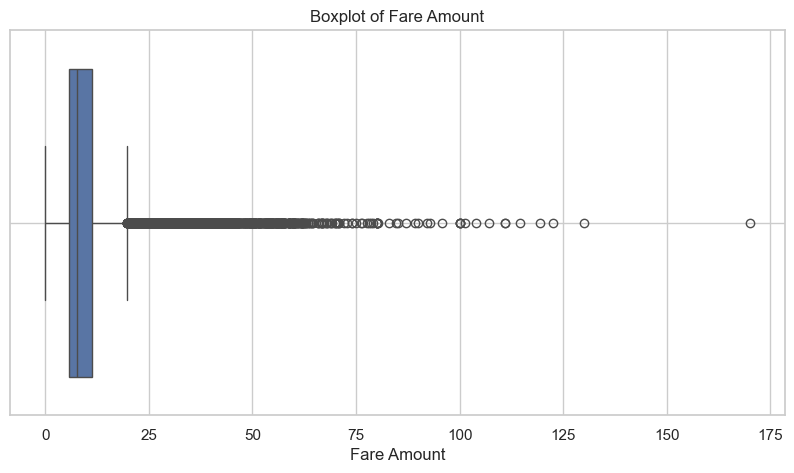

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Fare_Amt'])
plt.xlabel('Fare Amount')
plt.title('Boxplot of Fare Amount')
plt.grid(True)
plt.show()

The boxplot of the target variable Fare_Amt clearly reveals a significant number of outliers. While the majority of fare values are concentrated within a reasonable range, there are numerous extreme values extending far beyond the upper whisker of the boxplot.

These high-fare outliers can heavily skew the distribution and potentially impact model performance if not handled appropriately.

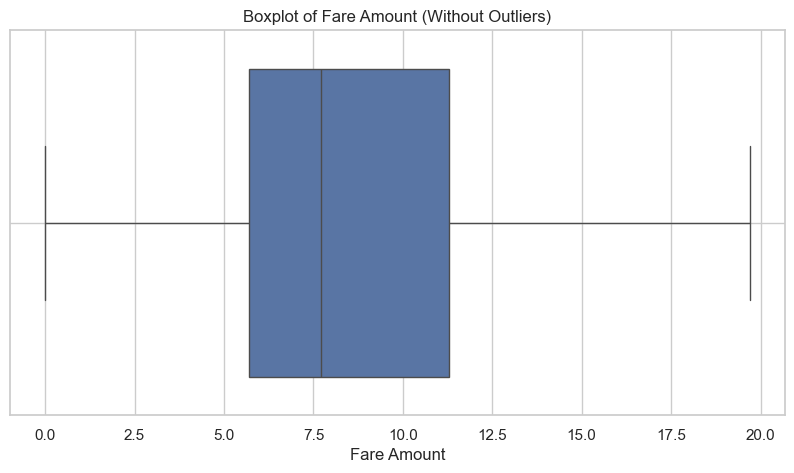

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Fare_Amt'], showfliers=False)
plt.xlabel('Fare Amount')
plt.title('Boxplot of Fare Amount (Without Outliers)')
plt.grid(True)
plt.show()

When these outliers are removed, the range of the boxplot reduces drastically, indicating that most fare values are actually concentrated within a much narrower and more typical interval.

This suggests that the distribution of fares is heavily skewed by a relatively small number of extreme values, reinforcing the importance of careful outlier treatment in the modeling pipeline.

# XGBRegressor

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from xgboost import XGBRegressor

We use joblib internally by setting n_jobs=-1 in XGBRegressor to enable parallel computation across all CPU cores,

speeding up model training and prediction without changing the output.

In [ ]:
X = df.drop(columns=['Fare_Amt'])
y = df['Fare_Amt']

kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

for fold, (train_index, val_index) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model = XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    results.append({'Fold': fold, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

In [ ]:
df_results = pd.DataFrame(results)
df_results.set_index('Fold', inplace=True)
df_results.loc['Average'] = df_results.mean(numeric_only=True)

In [ ]:
df_results

,RMSE,MAE,R2
Fold,,,
1,0.365562,0.065178,0.997616
2,0.403970,0.064570,0.996894
3,0.805620,0.068166,0.988695
4,0.937662,0.074147,0.984412
5,0.694295,0.079588,0.991989
6,0.799073,0.073721,0.988884
7,0.342603,0.058624,0.997807
8,0.363355,0.059551,0.997520
9,0.480704,0.068165,0.995701


The cross-validation results show that the XGBoost model is performing very well in predicting the fare amount. The average RMSE of 0.575 indicates that the prediction error is low, meaning the model is quite accurate in estimating the actual values. The average MAE of 0.068 confirms that the absolute error is also small, showing that the predictions are close to the observed values. The average R² of 0.993 reveals that the model is able to explain nearly all the variance in the data, which is an excellent indicator of model quality.

Despite the overall strong performance, there is some variation across the different folds. For example, folds 4 and 6 showed slightly higher errors, which may indicate that those data subsets are a bit more challenging to predict. Even so, the model remains highly stable, with consistent results across most groups.

In summary, the XGBoost model is effective and reliable for predicting fare amounts, showing low errors and strong data fit, with only minor variations across the validation groups.

# LogisticRegression

Similar to XGBRegressor, LogisticRegression can leverage joblib internally by setting n_jobs=-1,

enabling parallel computation during training and prediction to speed up processing.

In [ ]:
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

In [ ]:
features = df[['Fare_Amt', 'Trip_Distance', 'trip_duration_sec']]

# Scale features before clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=250)
df['Fare_class'] = clusterer.fit_predict(features_scaled)

# Optional: Remove noise points labeled -1 (unclustered)
df = df[df['Fare_class'] != -1]

# Check distribution of clusters
print(df['Fare_class'].value_counts())

c:\Users\InesNeves\anaconda3\envs\ML_cdle\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\InesNeves\anaconda3\envs\ML_cdle\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fare_class
29    1834
0     1481
8     1424
26    1404
18    1272
23    1149
13    1004
3      898
10     875
12     862
9      860
6      851
17     768
24     708
15     691
20     683
5      664
14     595
16     582
11     571
22     561
4      544
7      461
25     456
21     448
1      443
28     367
2      324
19     312
27     279
Name: count, dtype: int64


Scaling features with StandardScaler is important because LogisticRegression assumes input features are on a similar scale,

which improves model convergence and performance. Using HDBSCAN on these scaled features helps create meaningful clusters

(fare classes) that capture natural groupings in the data, leading to better-defined target classes for the classification task.

In [ ]:
# Prepare features and target
X = df.drop(columns=['Fare_Amt', 'Fare_class'])
y = df['Fare_class']

# Initialize Logistic Regression model
logreg = LogisticRegression(max_iter=2500, n_jobs=-1, random_state=42)

# Prepare Stratified K-Folds
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# Loop over folds
for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    logreg.fit(X_train, y_train)

    # Predict
    y_pred = logreg.predict(X_test)

    # Calculate metrics (macro average for multi-class)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({'Fold': fold_idx, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1_score': f1})

results_df = pd.DataFrame(results)

In [ ]:
# Add averages row
avg_metrics = results_df.mean(numeric_only=True)
avg_metrics['Fold'] = 'Average'
results_df = pd.concat([results_df, avg_metrics.to_frame().T], ignore_index=True)

C:\Users\InesNeves\AppData\Local\Temp\ipykernel_27004\3812265543.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Average' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  avg_metrics['Fold'] = 'Average'


In [ ]:
results_df

,Fold,Accuracy,Precision,Recall,F1_score
0,1,0.755346,0.676184,0.644645,0.632815
1,2,0.744116,0.666042,0.626238,0.608849
2,3,0.740265,0.661957,0.621628,0.600352
3,4,0.745828,0.644099,0.628868,0.613176
4,5,0.740693,0.634578,0.617816,0.595647
5,6,0.750535,0.639766,0.633931,0.618126
6,7,0.748823,0.630121,0.62981,0.610058
7,8,0.723577,0.644089,0.598723,0.575867
8,9,0.743688,0.642752,0.628651,0.607896
9,10,0.727428,0.60976,0.607168,0.585888


The cross-validation results indicate that the Logistic Regression model shows solid and consistent performance in classifying fare classes. The average accuracy of 0.742 suggests that the model correctly classifies a substantial portion of the data. In addition, the average precision of 0.645, recall of 0.624, and F1-score of 0.605 reflect a balanced performance between identifying correct classes and minimizing false positives or false negatives.

Although the model maintains steady results, there is some variation among folds. For instance, folds 8 and 10 recorded slightly lower F1-scores (around 0.58), indicating that the classification task was more challenging for those particular subsets. On the other hand, fold 1 showed the strongest performance overall, with all metrics at or above average, suggesting a more predictable data distribution in that fold.

In summary, the Logistic Regression model offers reliable and stable classification of fare clusters, with a balanced trade-off between precision and recall. While not perfect, the results are encouraging and show the model's ability to generalize well across different data splits.